In [1]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import sys

sys.path.insert(0, "../utils")

enc = 'utf-8'

In [2]:
df_extnord = pd.read_csv(f'../data/ExtNord/CM_ExtNord_Dataset_2015-2024.csv', encoding=enc)
df_nord = pd.read_csv(f'../data/Nord/CM_Nord_Dataset_2015-2024.csv', encoding=enc)

dataframe = pd.concat([df_extnord, df_nord], ignore_index=True)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

In [4]:
dataframe.head()

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2014-10,2014,10,-0.866,...,2,17,3,12,2,17,0,0,0,0
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2014-10,2014,10,-0.866,...,0,0,0,0,0,0,0,0,0,0
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2014-10,2014,10,-0.866,...,3,83,1,0,0,1,0,0,0,0
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2014-10,2014,10,-0.866,...,1,8,4,3,1,8,0,0,0,0
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2014-10,2014,10,-0.866,...,4,41,0,3,0,3,0,0,0,0


In [5]:
dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

In [6]:
dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [7]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [8]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109


In [9]:
bin_ranges = [0, 
              1,
              #2,
              #4, 
              8, 
              16, 
              32, 
              64, 
              128, 
              256, 
              512, 
              1024, 
              #2048, 
              #4096, 
              8192]

<Axes: title={'center': 'cases Distribution'}, xlabel='Bins', ylabel='Frequency'>

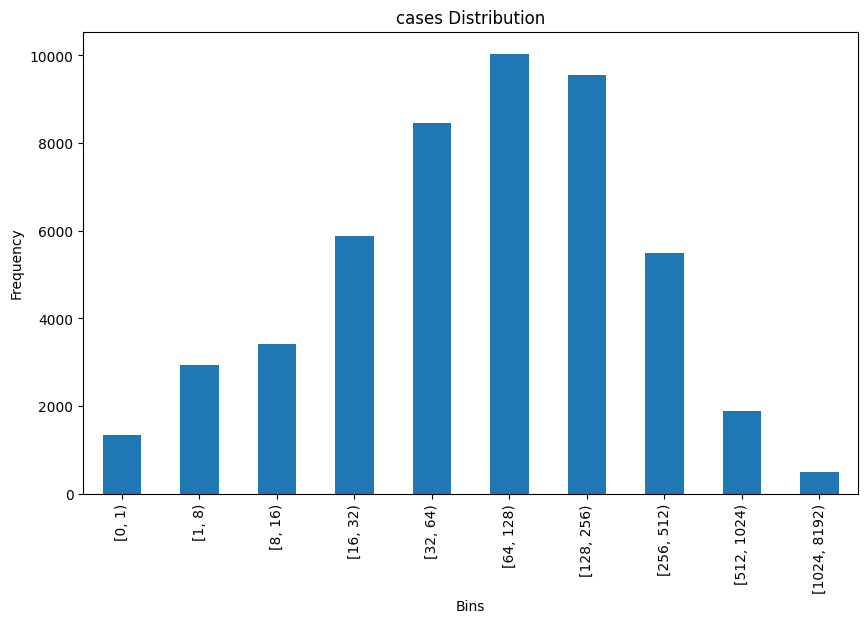

In [10]:
target_col = 'cases'

pd.cut(dataframe[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

In [11]:
risk_classes = list(range(0,10))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [12]:
data_rest = dataframe.copy()
data_rest.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109


In [13]:
bins, bounds = pd.qcut(x = data_rest.loc[:, 'cases'], q = 10, labels=risk_classes, retbins=True, precision=0)

In [14]:
data_rest['case_bin'] = bins

In [15]:
dataset = data_rest.copy()

In [16]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [17]:
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    9   21   36   54   77  108  151  216  345 8022]


In [21]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

[Text(0, 0, '[0-9]'),
 Text(1, 0, '(9-21)'),
 Text(2, 0, '(21-36]'),
 Text(3, 0, '(36-54]'),
 Text(4, 0, '(54-77]'),
 Text(5, 0, '(77-108]'),
 Text(6, 0, '(108-151]'),
 Text(7, 0, '(151-216]'),
 Text(8, 0, '(216-345]'),
 Text(9, 0, '345+')]

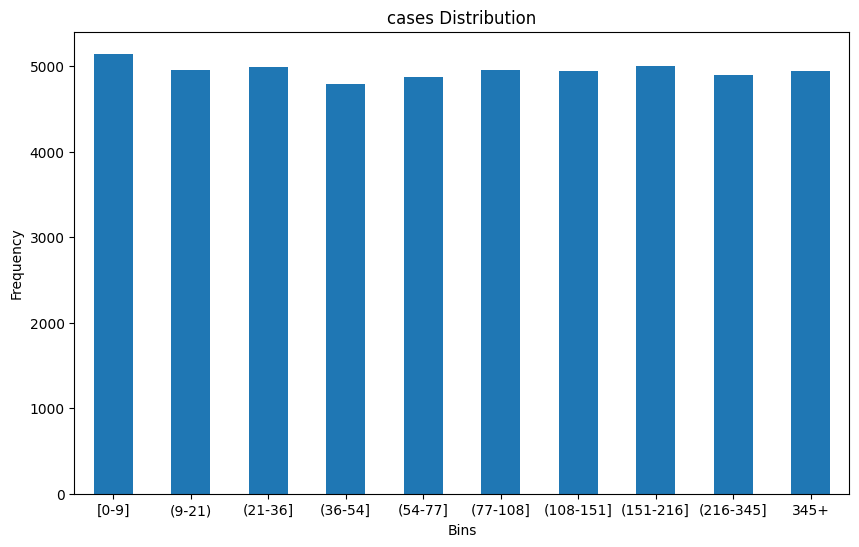

In [18]:
target_col = 'cases'

ax = dataset['case_bin'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6),
    title=f'{target_col} Distribution',
    xlabel='Bins',
    ylabel='Frequency'
)

# Set custom x-axis tick labels
ax.set_xticklabels(['[0-9]', '(9-21)', '(21-36]', '(36-54]','(54-77]','(77-108]','(108-151]','(151-216]','(216-345]','345+'], rotation=0) 
        

In [19]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94,5
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7,0
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91,5
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31,2
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49479,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-06,0.000,-1.0,0.513966,0.190414,-0.397487,-0.190414,...,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,66,4
49480,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-06,0.000,-1.0,0.402476,0.101305,-0.347630,-0.101305,...,2791.0,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,140,6
49481,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-06,0.000,-1.0,0.450903,0.092213,-0.381622,-0.092213,...,2842.0,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,708,9
49482,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-06,0.000,-1.0,0.454325,0.093292,-0.384450,-0.093292,...,2527.0,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,408,9


In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49484 entries, 0 to 49483
Data columns (total 70 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   location                 49484 non-null  object   
 1   x                        49484 non-null  float64  
 2   y                        49484 non-null  float64  
 3   dt_prediction            49484 non-null  period[M]
 4   month_sin                49484 non-null  float64  
 5   month_cos                49484 non-null  float64  
 6   ndvi                     49392 non-null  float64  
 7   ndmi                     49392 non-null  float64  
 8   ndwi                     49392 non-null  float64  
 9   ndbi                     49392 non-null  float64  
 10  ndvi_mean                49457 non-null  float64  
 11  ndmi_mean                49457 non-null  float64  
 12  ndwi_mean                49457 non-null  float64  
 13  ndbi_mean                49457 non-null  float64  


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

In [22]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['x', 'y', 'cases', 'case_bin'])
y = dataset['case_bin']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [25]:
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

In [26]:
model_params = {
    "num_class": 10,
    "objective": "multi:softmax",
    "device": "cpu", 
    "eval_metric": "mlogloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    #"min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 6,                 #default 6, range[0,inf], large values lead to overfitting
    #"reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    #"reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    #"min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "n_estimators": 100,
    "random_state": 42
}

In [27]:
model = xgb.XGBClassifier(**model_params)   

In [28]:
fitted_model = model.fit(X_train_imputed, y_train)

In [29]:
y_train_prob = fitted_model.predict_proba(X_train_imputed)
y_test_prob = fitted_model.predict_proba(X_test_imputed)

In [30]:
y_train_pred = np.argmax(y_train_prob, axis=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

In [31]:
print("\n Classification Report Test:\n",
      classification_report(y_train, y_train_pred))


 Classification Report Test:
               precision    recall  f1-score   support

           0       0.76      0.90      0.82      4114
           1       0.73      0.79      0.76      3963
           2       0.79      0.75      0.77      3990
           3       0.83      0.74      0.78      3832
           4       0.84      0.71      0.77      3901
           5       0.84      0.72      0.77      3966
           6       0.81      0.75      0.78      3951
           7       0.75      0.79      0.77      3996
           8       0.74      0.82      0.78      3918
           9       0.85      0.93      0.89      3956

    accuracy                           0.79     39587
   macro avg       0.79      0.79      0.79     39587
weighted avg       0.79      0.79      0.79     39587



In [32]:
print("\n Classification Report Test:\n",
      classification_report(y_test, y_test_pred))


 Classification Report Test:
               precision    recall  f1-score   support

           0       0.47      0.59      0.53      1029
           1       0.29      0.34      0.31       990
           2       0.22      0.20      0.21       998
           3       0.18      0.14      0.16       958
           4       0.20      0.15      0.17       975
           5       0.20      0.15      0.17       992
           6       0.19      0.17      0.18       988
           7       0.24      0.25      0.25       999
           8       0.34      0.42      0.37       979
           9       0.63      0.70      0.67       989

    accuracy                           0.31      9897
   macro avg       0.30      0.31      0.30      9897
weighted avg       0.30      0.31      0.30      9897



In [33]:
from XGboost_Model_Module import Xgboost_model
from Model_Validation_Module import evaluate_xgboost, validation

In [34]:
data = X
data['case_bin'] = y

In [35]:
dataset['case_bin'] = data['case_bin'].astype('category').cat.as_ordered()

In [36]:
dataset.drop(columns=['location', 'cases'], inplace=True)

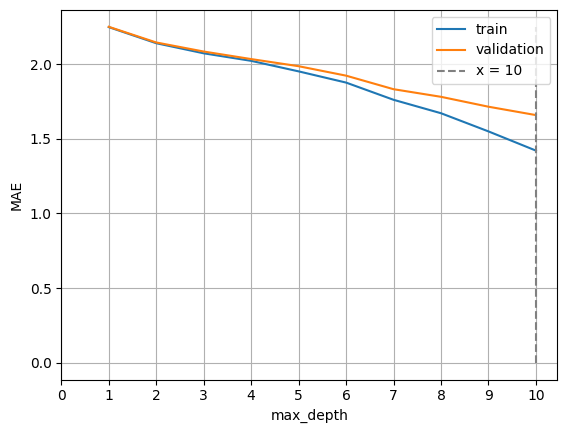

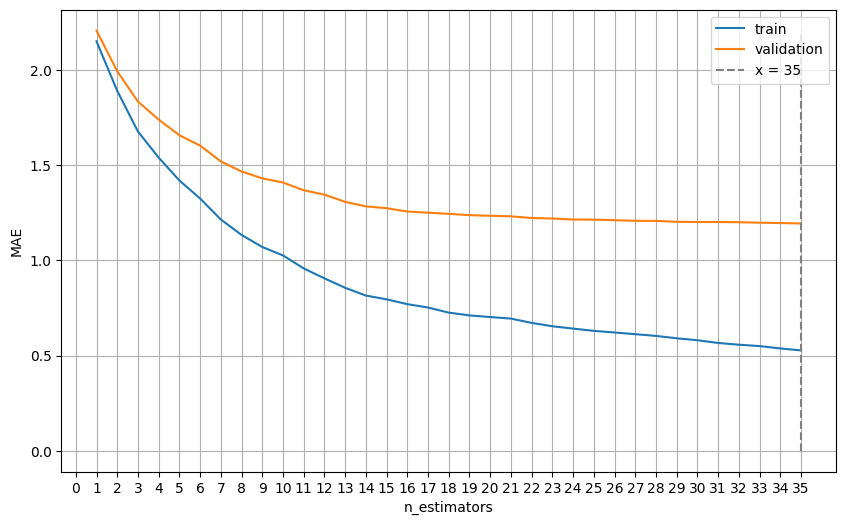

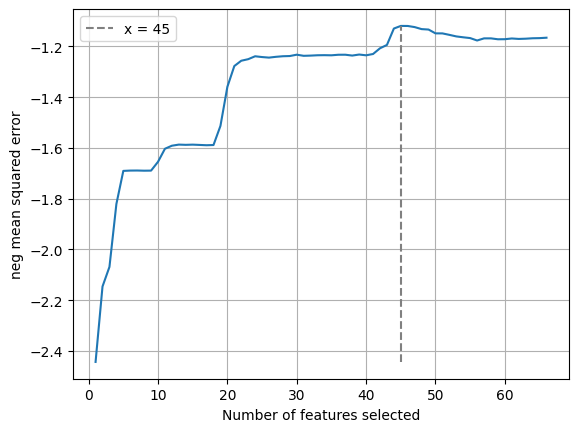

max_depth:  10
Number of estimators:  35
Selected_features:  Index(['x', 'y', 'month_cos', 'rainfall', 'rainfall_acc_prev_month',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std',
       'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std',
       'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std',
       'flow_accu_200m_std', 'lc_prop1', 'lc_prop2', 'lc_type2', 'lc_type4',
       'lc_type5', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7',
       'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15',
       'bio16', 'bio17', 'bio18', 'bio19'],
      dtype='object')


In [37]:
model = Xgboost_model(model_type = 'class_regression', learning_rate = 0.3,
                          embedding_data = None,  transformation_list = [],
                          early_stop = False, l1_weight = 0, l2_weight = 0, weights = False)
    
results_train, results_test, test, date, mosq_col = evaluate_xgboost(model, dataset, fi = False, error_buffer=3, date_col='dt_prediction')

In [38]:
test['dt_prediction'] = date
#test['dt_prediction'] = test[date_col] + datetime.timedelta(days=15)
test['prediction'] = results_test['prediction']
test['prediction'] = test['prediction'].astype('Int64')
test['error'] = test[mosq_col].cat.codes - test['prediction']
test['abs(error)'] = np.abs(test[mosq_col].cat.codes - test['prediction'])

In [39]:
test = test.rename(columns={mosq_col:'actual'})

In [40]:
test['actual'] = test['actual'].cat.codes

MAE on train set:  0.5672821885972668
min prediction: -0.0
max prediction: 9.0

MAE on test set:  1.0784075982620995
Error <= 3: 97.43 %
min prediction: 0
max prediction: 9


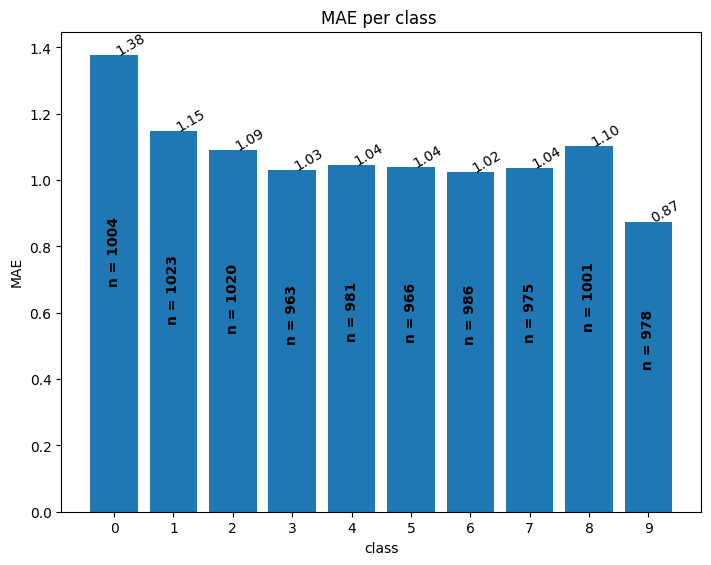

-----------|class error-MAE| difference-----------
mean: 0.20286266130808933
std: 0.12117613258543243
coefficient of variation (std/mean): 0.5973308828942215

----------normalized difference-------------
mean: 0.4023033887737988
std: 0.24030823840759047


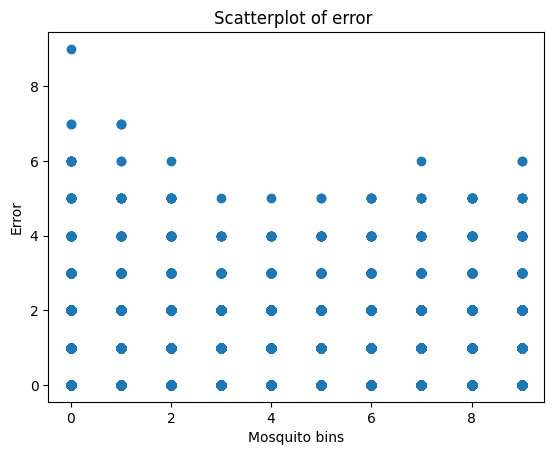

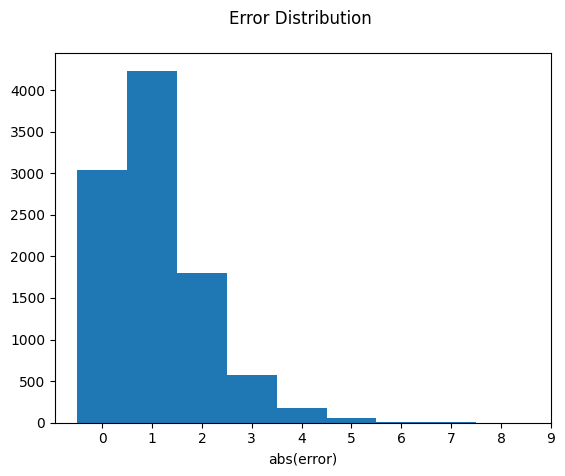

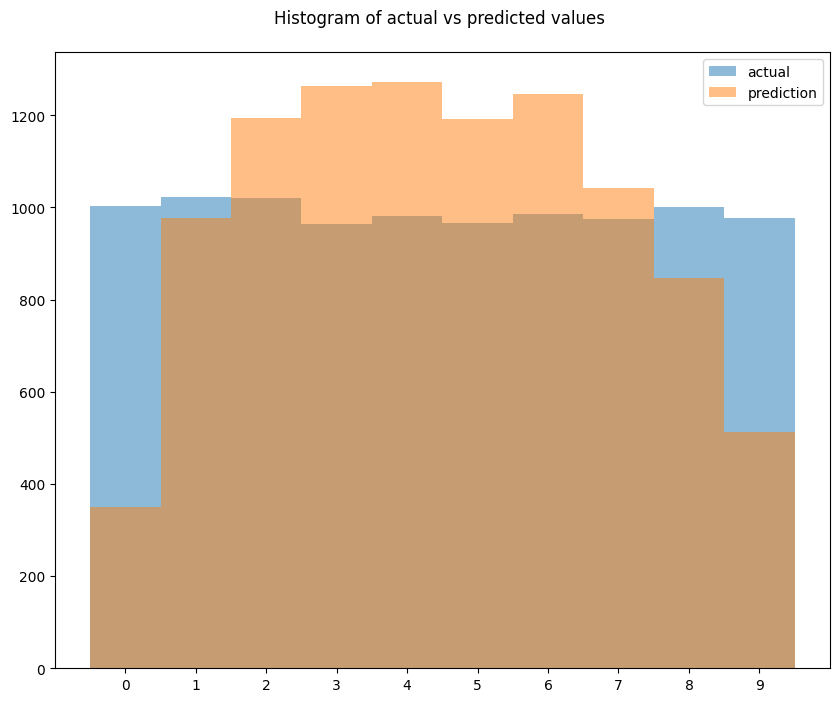

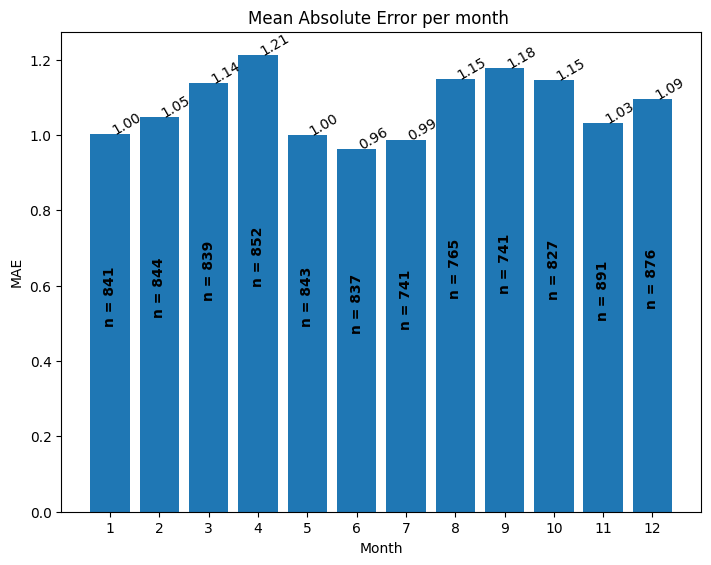

In [41]:
validation(results_train, test, model_type=model.model_type, case = '', error_buffer=3)